In [1]:
from data_driven_on_policy_natural import NaturalPG_on_policy
import numpy as np
import sympy as sp
import math
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
A = -1
B = 1
# data generating sigma
sigma=0.1
M=1.0
N=1.0
lambda_reg=0.1
beta=1.0
# iteration parameters
omega_init = [0.5 , 1, 1]
eta_natural = 0.01  # step size for natural policy gradient
max_iter = 3000  # maximum iteration
T_f = 0.1
dt = 0.1
N_traj = 1000

#epsilon = 0.2

omega1, omega2, omega3 = sp.symbols('omega1 omega2 omega3')

k_2_o =  - (M + N*omega1**2) / (beta - 2*(A + B*omega1))
k_1_o = ( B * omega2 * k_2_o - N * omega1 * omega2) / (beta - A - B*omega1)
# k_0_o = (1/beta) * ( -N/2 * (omega2**2 + omega3**2) + lambda_reg * ( 1/2*np.log(2*math.pi) + sp.log(omega3) + 1/2)
#             + B * omega2 * k_1_o + 0.5 * sigma**2 * k_2_o)

# no diffusion term in PhiBE setting
k_0_o = (1/beta) * ( -N/2 * (omega2**2 + omega3**2) + lambda_reg * ( 1/2*np.log(2*math.pi) + sp.log(omega3) + 1/2)
            + B * omega2 * k_1_o)

k_2_o_func = sp.lambdify((omega1, omega2, omega3), k_2_o, 'numpy')
k_1_o_func = sp.lambdify((omega1, omega2, omega3), k_1_o, 'numpy')
k_0_o_func = sp.lambdify((omega1, omega2, omega3), k_0_o, 'numpy')

# true solution
k2 = N/B**2 * ( beta/2 - A - np.sqrt( (beta/2 - A)**2 + B**2 * M / N ) )
k1 = 0
k0 = - lambda_reg/(2*beta) * np.log( N/(2*math.pi*lambda_reg) ) + sigma**2 * k2 / (2*beta)

In [5]:
def phibe_closed_form_optimum(
    beta,
    dt,
    A=-1.0,
    B=1.0,
    sigma=1.0,
    M=1.0,
    N=1.0,
    lambda_reg=0.1,
):
    # --------------------------------------------------------
    # Discretized PhiBE coefficients
    # --------------------------------------------------------
    A_t = (np.exp(A * dt) - 1.0) / dt

    if abs(A) < 1e-12:
        B_t = B
        # limit as A -> 0
        sigma_t2 = sigma**2
    else:
        B_t = B * (np.exp(A * dt) - 1.0) / (A * dt)
        sigma_t2 = sigma**2 * (np.exp(2.0 * A * dt) - 1.0) / (2.0 * A * dt)

    if abs(B_t) < 1e-14:
        raise ValueError("B_t is too close to zero, closed-form control coefficient is undefined.")
    if N <= 0:
        raise ValueError("N must be positive.")
    if lambda_reg <= 0:
        raise ValueError("lambda_reg must be positive.")
    if beta <= 0:
        raise ValueError("beta must be positive.")

    # --------------------------------------------------------
    # Closed-form value function coefficients
    # V(s) = 0.5 * k2 * s^2 + k1 * s + k0
    # obtained by direct substitution:
    #   A -> A_t, B -> B_t, sigma^2 -> sigma_t2
    # --------------------------------------------------------
    radicand = (A_t - 0.5 * beta) ** 2 + (M * B_t**2) / N
    sqrt_term = np.sqrt(radicand)

    k2_star = (N / (B_t**2)) * (0.5 * beta - A_t - sqrt_term)
    k1_star = 0.0
    k0_star = -(lambda_reg / (2.0 * beta)) * np.log(N / (2.0 * np.pi * lambda_reg)) \
              + (sigma_t2 / (2.0 * beta)) * k2_star

    # --------------------------------------------------------
    # Optimal Gaussian policy:
    # pi*(a|s) = N( (B_t/N) * (k2 s + k1), lambda_reg / N )
    # so in the parameterization a|s ~ N(omega1*s + omega2, omega3^2):
    # --------------------------------------------------------
    w1_star = (B_t / N) * k2_star
    w2_star = (B_t / N) * k1_star
    w3_star = np.sqrt(lambda_reg / N)

    return {
        "omega1": w1_star,
        "omega2": w2_star,
        "omega3": w3_star,
        "k2": k2_star,
        "k1": k1_star,
        "k0": k0_star,
        "A_t": A_t,
        "B_t": B_t,
        "sigma_t2": sigma_t2,
    }

Running final-iterate comparison for T_f = dt = 0.00100
Running final-iterate comparison for T_f = dt = 0.00127
Running final-iterate comparison for T_f = dt = 0.00161
Running final-iterate comparison for T_f = dt = 0.00204
Running final-iterate comparison for T_f = dt = 0.00259
Running final-iterate comparison for T_f = dt = 0.00329
Running final-iterate comparison for T_f = dt = 0.00418
Running final-iterate comparison for T_f = dt = 0.00530
Running final-iterate comparison for T_f = dt = 0.00672
Running final-iterate comparison for T_f = dt = 0.00853
Running final-iterate comparison for T_f = dt = 0.01083
Running final-iterate comparison for T_f = dt = 0.01374
Running final-iterate comparison for T_f = dt = 0.01743
Running final-iterate comparison for T_f = dt = 0.02212
Running final-iterate comparison for T_f = dt = 0.02807
Running final-iterate comparison for T_f = dt = 0.03562
Running final-iterate comparison for T_f = dt = 0.04520
Running final-iterate comparison for T_f = dt = 

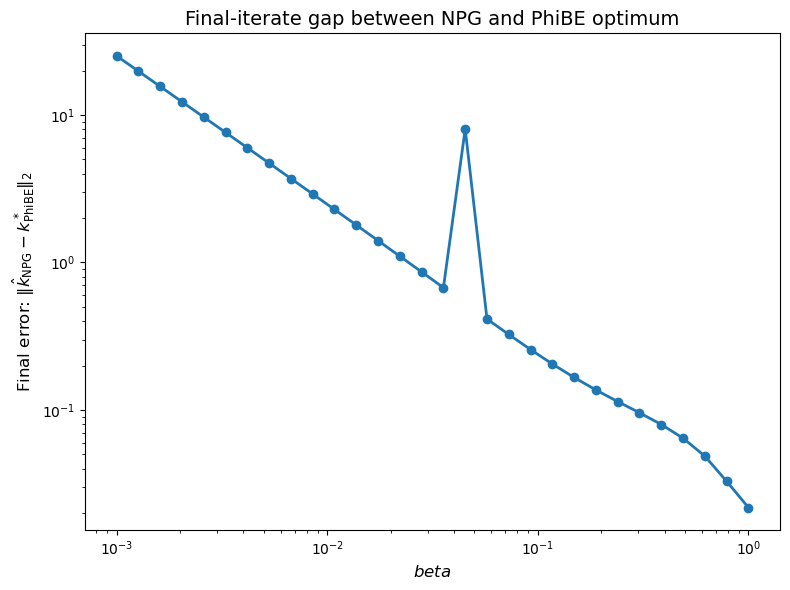

In [7]:
def value_from_k(s, k):
    k2, k1, k0 = k
    return 0.5 * k2 * s**2 + k1 * s + k0

beta_grid = np.logspace(-3, 0, 30)  
rows = []

for beta_val in beta_grid:
    print("=" * 70)
    print(f"Running final-iterate comparison for T_f = dt = {beta_val:.5f}")

    # --------------------------------------------------------
    # PhiBE optimum for this dt
    # --------------------------------------------------------
    phibe_ref = phibe_closed_form_optimum(
        beta=beta_val,
        dt=dt,
        A=A,
        B=B,
        sigma=sigma,
        M=M,
        N=N,
        lambda_reg=lambda_reg,
    )

    k_true_phibe = np.array([
        phibe_ref["k2"],
        phibe_ref["k1"],
        phibe_ref["k0"],
    ])

    omega_true_phibe = np.array([
        phibe_ref["omega1"],
        phibe_ref["omega2"],
        phibe_ref["omega3"],
    ])

    # --------------------------------------------------------
    # Run NPG
    # --------------------------------------------------------
    npg = NaturalPG_on_policy(
        A=A,
        B=B,
        sigma=sigma,
        M=M,
        N=N,
        lambda_reg=lambda_reg,
        beta=beta_val,
        learning_rate=eta_natural,
        T=dt,
        dt=dt,
        n_traj=1000,
        max_iter=500,
    )

    final_omega, omega_history_npg, grad_history_npg, _, _, _ = npg.run_single_trial(
        omega_init=omega_init,
        verbose=False
    )

    # find valid iterations
    valid_mask = np.any(omega_history_npg != 0, axis=1)
    iter_na = np.sum(valid_mask)

    omega_hist_valid = omega_history_npg[:iter_na, :]

    # map omega -> (k2, k1, k0)
    k_history_na = np.zeros((iter_na, 3))
    for i in range(iter_na):
        omega = omega_hist_valid[i, :]
        k_history_na[i, :] = [
            k_2_o_func(omega[0], omega[1], omega[2]),
            k_1_o_func(omega[0], omega[1], omega[2]),
            k_0_o_func(omega[0], omega[1], omega[2]),
        ]

    # # --------------------------------------------------------
    # # Map final NPG omega to dt-dependent PhiBE value coeffs
    # # --------------------------------------------------------
    # omega_final = omega_hist_valid[-1, :]
    # coeffs_final = phibe_value_coeffs_from_omega(
    #     omega1=omega_final[0],
    #     omega2=omega_final[1],
    #     omega3=omega_final[2],
    #     beta=beta,
    #     dt=dt_val,
    #     A=A,
    #     B=B,
    #     sigma=sigma,
    #     M=M,
    #     N=N,
    #     lambda_reg=lambda_reg,
    #     include_diffusion=True,
    # )

    # k_final_npg = np.array([
    #     coeffs_final["k2"],
    #     coeffs_final["k1"],
    #     coeffs_final["k0"],
    # ])

    # --------------------------------------------------------
    # Errors at FINAL iteration
    # --------------------------------------------------------
    s_grid = np.linspace(-3.0, 3.0, 100)

    k_final_npg = k_history_na[-1, :]
    omega_final = omega_hist_valid[-1, :]
    V_npg_grid = value_from_k(s_grid, k_final_npg)
    V_phibe_grid = value_from_k(s_grid, k_true_phibe)
    V_diff_grid = V_npg_grid - V_phibe_grid

    # --------------------------------------------------------
    # Errors on value function
    # --------------------------------------------------------
    value_rmse_final = np.sqrt(np.mean(V_diff_grid**2))
    value_mae_final = np.mean(np.abs(V_diff_grid))
    value_max_final = np.max(np.abs(V_diff_grid))
    k_error_final = np.linalg.norm(k_final_npg - k_true_phibe)
    omega_error_final = np.linalg.norm(omega_final - omega_true_phibe)

    rows.append({
        "beta": beta_val,
        "dt": dt,
        "T_f": dt,
        "omega1_final": omega_final[0],
        "omega2_final": omega_final[1],
        "omega3_final": omega_final[2],
        "omega1_phibe": omega_true_phibe[0],
        "omega2_phibe": omega_true_phibe[1],
        "omega3_phibe": omega_true_phibe[2],
        "k2_final": k_final_npg[0],
        "k1_final": k_final_npg[1],
        "k0_final": k_final_npg[2],
        "k2_phibe": k_true_phibe[0],
        "k1_phibe": k_true_phibe[1],
        "k0_phibe": k_true_phibe[2],
        "k_error_final": k_error_final,
        "omega_error_final": omega_error_final,
        "value_rmse_final": value_rmse_final,
        "value_mae_final": value_mae_final,
        "value_max_final": value_max_final,
    })

# ============================================================
# Make dataframe
# ============================================================
df_final_compare = pd.DataFrame(rows).sort_values("beta").reset_index(drop=True)
#display(df_final_compare)

# ============================================================
# Plot: final value-function error vs dt
# ============================================================
plt.figure(figsize=(8, 6))
plt.loglog(df_final_compare["beta"], df_final_compare["k_error_final"], marker="o", linewidth=2)
plt.xlabel(r"$beta$", fontsize=12)
plt.ylabel(r"Final error: $\|\hat{k}_{\mathrm{NPG}} - k^*_{\mathrm{PhiBE}}\|_2$", fontsize=12)
plt.title("Final-iterate gap between NPG and PhiBE optimum", fontsize=14)
plt.tight_layout()
plt.show()

Estimated log-log slope = -0.979251
Estimated intercept     = -3.512469


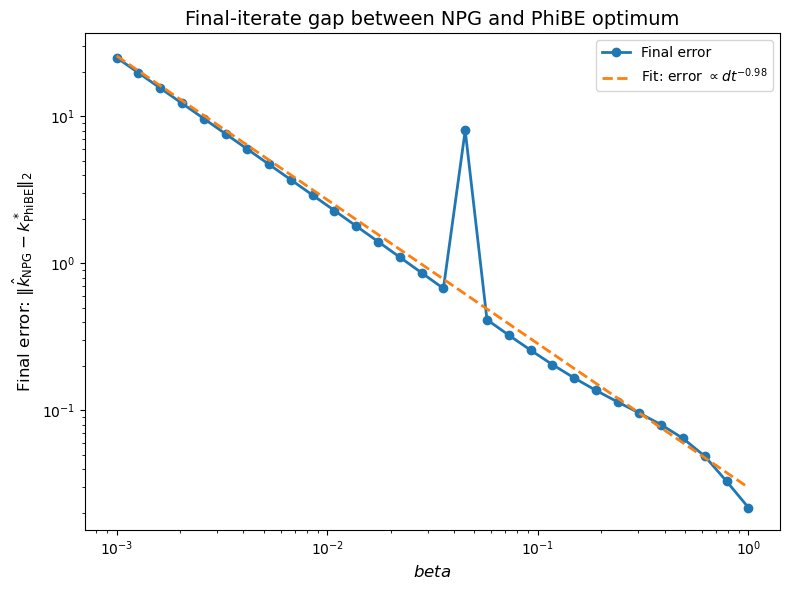

In [9]:
# ============================================================
# Prepare positive data only
# ============================================================
df_plot = df_final_compare.copy()
df_plot = df_plot[(df_plot["beta"] > 0) & (df_plot["k_error_final"] > 0)].copy()
df_plot = df_plot.sort_values("beta").reset_index(drop=True)

x = df_plot["beta"].values
y = df_plot["k_error_final"].values

# log-transform
logx = np.log(x)
logy = np.log(y)

# ============================================================
# Estimate global slope on log-log scale
# log(y) = slope * log(x) + intercept
# ============================================================
slope, intercept = np.polyfit(logx, logy, 1)

print(f"Estimated log-log slope = {slope:.6f}")
print(f"Estimated intercept     = {intercept:.6f}")

# fitted curve in original scale
y_fit = np.exp(intercept) * x**slope

# ============================================================
# Plot original log-log curve + fitted line
# ============================================================
plt.figure(figsize=(8, 6))
plt.loglog(x, y, marker="o", linewidth=2, label="Final error")
plt.loglog(
    x, y_fit, "--", linewidth=2,
    label=rf"Fit: error $\propto dt^{{{slope:.2f}}}$"
)
plt.xlabel(r"$beta$", fontsize=12)
plt.ylabel(r"Final error: $\|\hat{k}_{\mathrm{NPG}} - k^*_{\mathrm{PhiBE}}\|_2$", fontsize=12)
plt.title("Final-iterate gap between NPG and PhiBE optimum", fontsize=14)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()